# Imports

In [1]:
import os
import sys

In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{bm}", # Recomendado para negritas matemáticas
})

In [3]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [4]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [6]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [7]:
dir = "./../../data/uvtable/"
data_file = dir + "uvtable_SimulatedBlob.txt"
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1

# Load data
file = np.loadtxt(data_file, unpack=True)
u, v, Re, Im, Weights = file
Vis = Re + 1j * Im
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

## F2D

In [90]:
Rmax = 3*rout
Qmax = max(np.hypot(u,v))

import math

N = math.floor(5* Rmax/rad_to_arcsec * Qmax)

In [175]:
N

642

In [91]:
best_N50_Rmax3 = {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}


In [92]:
l_wend =[9000.0, 10000.0, 20000.0, 40000.0, 50000.0, best_N50_Rmax3['l'], 100000.0]

### Wendland

In [93]:
frank2d_wend = Frank2D(N, Rmax)

In [94]:
frank2d_wend.process_vis(uvtable)

===>  Setting gridded data...


In [95]:
frank2d_wend.set_kernel(kernel_type = "wend", kernel_params = best_N50_Rmax3)
frank2d_wend.set_x0(None)

===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}


In [96]:
frank2d_wend.set_fit_method()

In [97]:
WEND = frank2d_wend._kernel.sparse_matrix()

In [98]:
tick_positions_y = [0, 700,1000,  3995]
tick_labels_y = [
    r"$(u, v)_{0}$",
    r"$(u, v)_{N}$",
    r"$(u, v)_{N+1}$",
    r"$(u, v)_{N^{2}}$",
]

tick_positions_x = [0, 700,  3995]
tick_labels_x = [
    r"$(u, v)_{0}$",
    r"$(u, v)_{N}$",
    r"$(u, v)_{N^{2}}$",
]

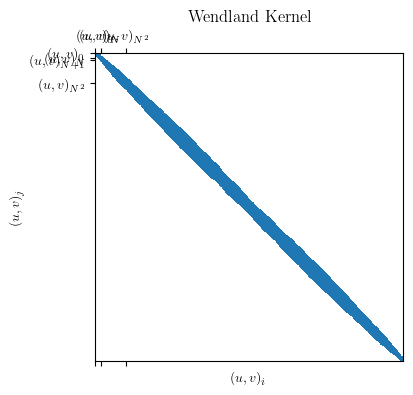

In [99]:
plt.figure(figsize=(4, 4))
plt.spy(WEND, markersize=1)
plt.title("Wendland Kernel")
plt.xlabel("Índice de Columna")
plt.ylabel("Índice de Fila")
plt.xlabel(r'$(u, v)_i$')
plt.ylabel(r'$(u, v)_j$')
plt.xticks(tick_positions_x, tick_labels_x)
plt.yticks(tick_positions_y, tick_labels_y)
#plt.xlim(0, 4000)
#plt.ylim(0, 4000)
plt.show()

In [100]:
times_wend = []

In [101]:
frank2d_objects_wend = []

In [102]:
for i in l_wend:
    start_time = time.time()
    params = {'m': best_N50_Rmax3['m'], 'c': best_N50_Rmax3['c'], 'l': i}
    frank2d_wend = Frank2D(N, Rmax)
    frank2d_wend.fit(uvtable, kernel_type='wend', kernel_params = params, rtol = 1e-10)
    frank2d_objects_wend.append(frank2d_wend)
    end_time = time.time()
    times_wend.append(end_time - start_time)

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 9000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.01  min |  0.79 seconds
        +  Building system = 0.01  min |  0.80 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 0/50000 [00:00<?, ? iterations/s]

            +  BiCGStab = 0.00  min |  0.05 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417657,
 'iterations': 0,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...


     + Setting kernel..
--> time building S_12_T = 0.11  min |  6.41 seconds
--> times building full visibility model = 0.11  min |  6.42 seconds
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 10000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.01  min |  0.85 seconds
        +  Building system = 0.01  min |  0.85 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 2/50000 [00:00<1:05:19, 12.76 iterations/s]

...

            +  BiCGStab = 0.24  min |  14.32 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417657,
 'iterations': 199,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.12  min |  7.20 seconds
--> times building full visibility model = 0.12  min |  7.23 seconds
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  2.06 seconds
        +  Building system = 0.04  min |  2.12 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   1%|          | 279/50000 [00:23<1:11:11, 11.64 iterations/s]


            +  BiCGStab = 0.40  min |  23.97 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417657,
 'iterations': 279,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.12  min |  7.41 seconds
--> times building full visibility model = 0.12  min |  7.44 seconds
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 100000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.07  min |  4.40 seconds
        +  Building system = 0.08  min |  4.56 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   7%|▋         | 3382/50000 [07:07<1:38:12,  7.91 iterations/s]


            +  BiCGStab = 7.13  min |  427.51 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417657,
 'iterations': 3382,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.15  min |  9.20 seconds
--> times building full visibility model = 0.15  min |  9.28 seconds


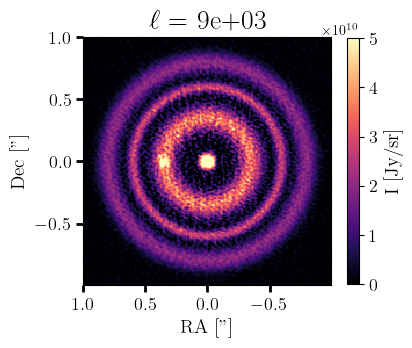

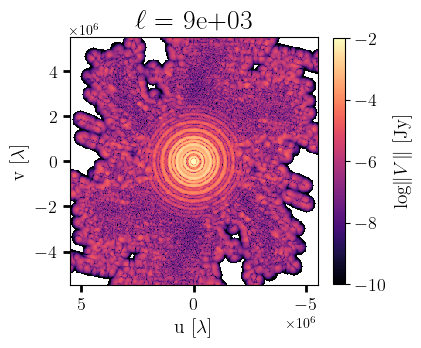

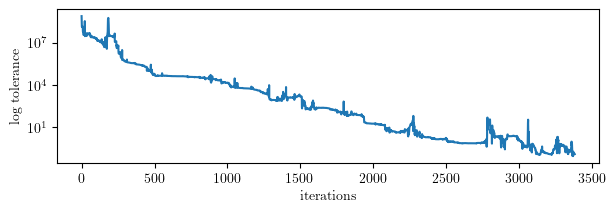

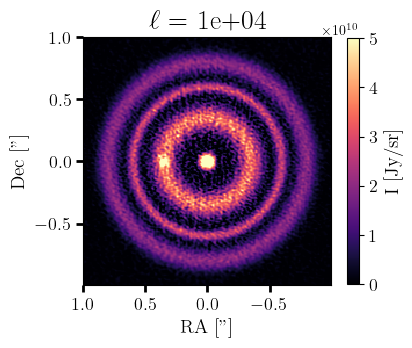

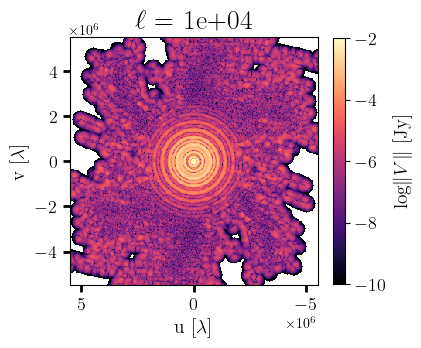

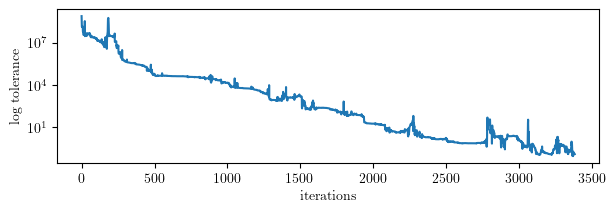

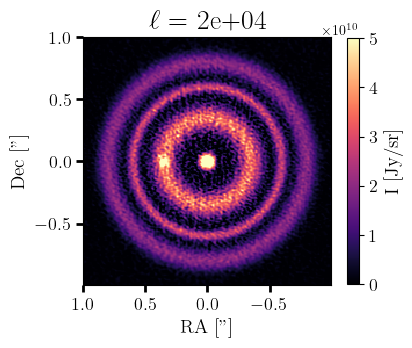

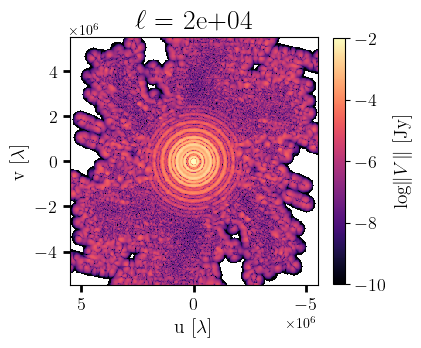

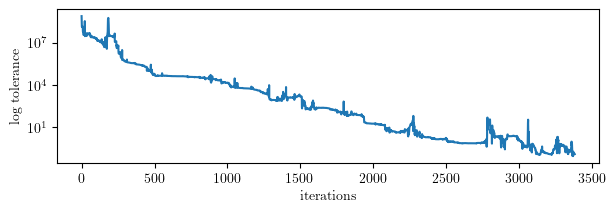

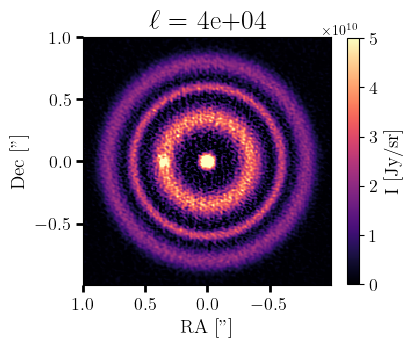

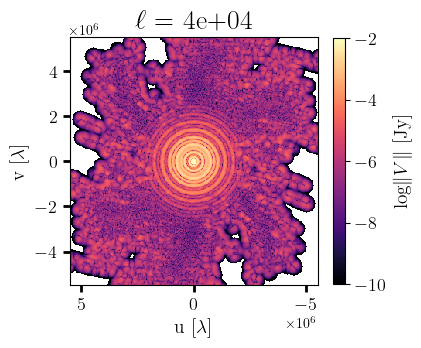

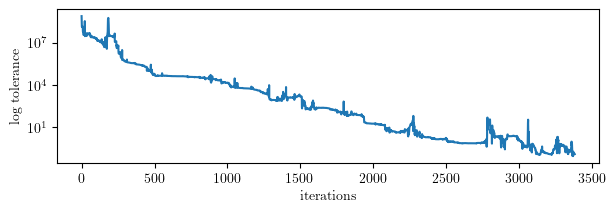

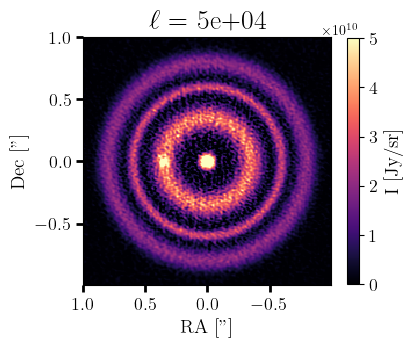

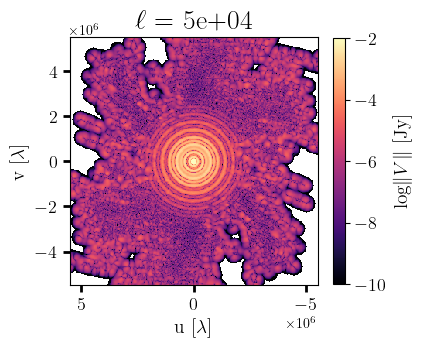

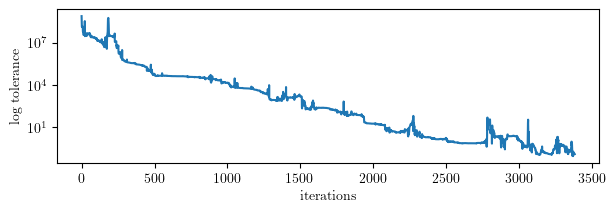

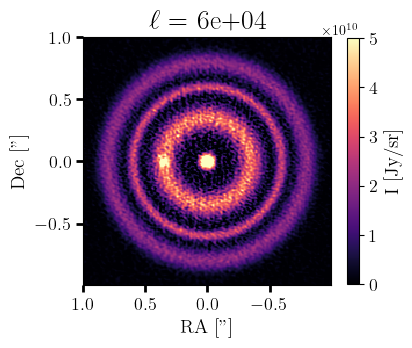

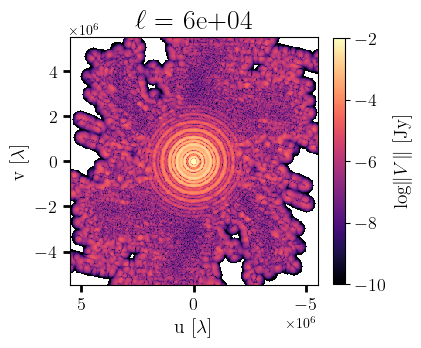

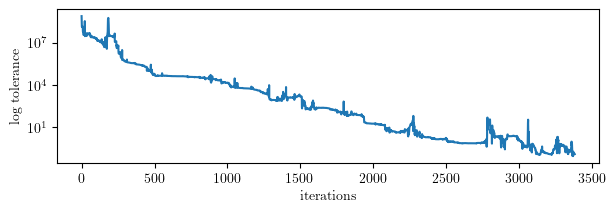

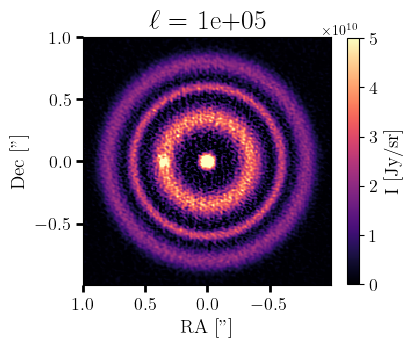

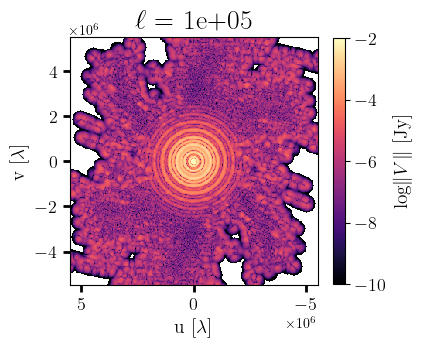

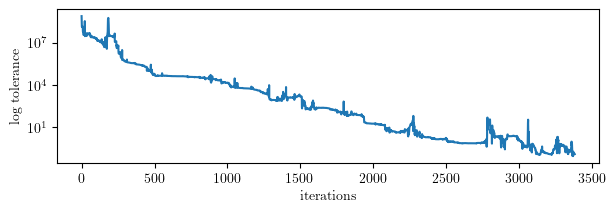

In [174]:
for i in l_wend:
    Plot_wend = Plot(frank2d_wend, geom)
    Plot_wend.intensity(fig_size = 4, vmax=5e10, gamma = 1, zoom = 3, title = r'' + f'$\ell$ = {i:.0e}')
    Plot_wend.visibility(fig_size = 4, zoom=2, title = r'' + f'$\ell$ = {i:.0e}')
    Plot_wend.cg_tolerance()

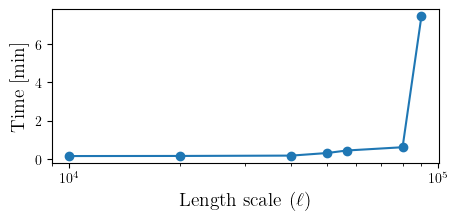

In [104]:
# plot times
plt.figure(figsize=(5,2))
plt.plot(l, np.array(times_wend)/60, marker='o')
plt.xscale('log')
plt.xlabel(r'Length scale ($\ell$)', size=14)
plt.ylabel(' Time [min]', size=14)
plt.show()

#### SE Kernel

In [105]:
frank2d_se = Frank2D(N, Rmax)

In [106]:
frank2d_se.process_vis(uvtable)

===>  Setting gridded data...


In [107]:
frank2d_se.set_kernel(kernel_type = "sqexp", kernel_params = best_N50_Rmax3)
frank2d_se.set_x0(None)

===>  Setting GP Kernel sqexp...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}


In [108]:
frank2d_se.set_fit_method()

In [109]:
SE = frank2d_se._kernel.sparse_matrix()

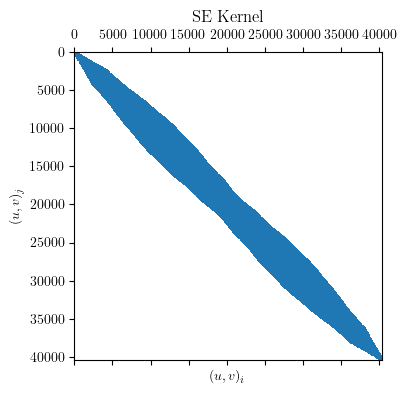

In [110]:
plt.figure(figsize=(4, 4))
plt.spy(SE, markersize=1)
plt.title("SE Kernel")
plt.xlabel(r'$(u, v)_i$')
plt.ylabel(r'$(u, v)_j$')
#plt.xlim(0, 4000)
#plt.ylim(0, 4000)
plt.show()

In [111]:
frank2d_objects_se = []
times_se = []

In [112]:
l

[10000.0, 20000.0, 40000.0, 50000.0, 56439.474897224536, 80000.0, 90000.0]

In [122]:
l_se =[9000.0, 10000.0, 20000.0, 40000.0, 50000.0, best_N50_Rmax3['l'], 100000.0]

In [114]:
for i in l_se:
    if i > 5e4:
        pass
    else:
        start_time = time.time()
        params = {'m': best_N50_Rmax3['m'], 'c': best_N50_Rmax3['c'], 'l': i}
        frank2d_se = Frank2D(N, Rmax)
        frank2d_se.fit(
                        data = uvtable,
                        kernel_params = params , rtol = 1e-10, 
                        kernel_type = 'sqexp'
                    )
        frank2d_objects_se.append(frank2d_se)
        end_time = time.time()
        times_se.append(end_time - start_time)
    

===>  Setting gridded data...
===>  Setting GP Kernel sqexp...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 9000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.01  min |  0.85 seconds
        +  Building system = 0.01  min |  0.87 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 2/50000 [00:00<1:09:27, 12.00 iterations/s]

            +  BiCGStab = 0.00  min |  0.17 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of r',
 'final_tol': 0.07435963551417657,
 'iterations': 2,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...


     + Setting kernel..
--> time building S_12_T = 0.01  min |  0.88 seconds
--> times building full visibility model = 0.01  min |  0.90 seconds
===>  Setting gridded data...
===>  Setting GP Kernel sqexp...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 10000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.02  min |  0.93 seconds
        +  Building system = 0.02  min |  0.95 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 2/50000 [00:00<1:13:23, 11.35 iterations/s]

...

         + Fitting with BiCGStab...:   0%|          | 15/50000 [00:01<1:11:11, 11.70 iterations/s]


            +  BiCGStab = 0.02  min |  1.28 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of r',
 'final_tol': 0.07435963551417657,
 'iterations': 15,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.04  min |  2.19 seconds
--> times building full visibility model = 0.04  min |  2.23 seconds
===>  Setting gridded data...
===>  Setting GP Kernel sqexp...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 40000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.10  min |  6.07 seconds
        +  Building system = 0.11  min |  6.35 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 27/50000 [00:04<2:21:23,  5.89 iterations/s]

         + Fitting with BiCGStab...:  12%|█▏        | 5798/50000 [16:26<2:05:23,  5.87 iterations/s]


KeyboardInterrupt: 

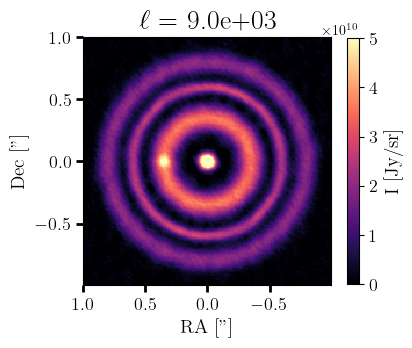

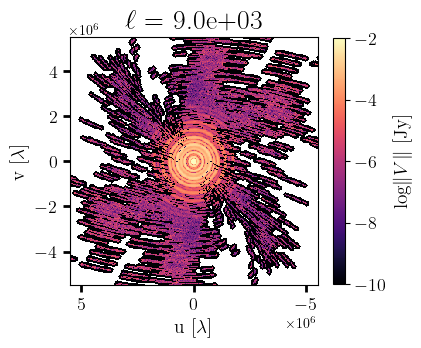

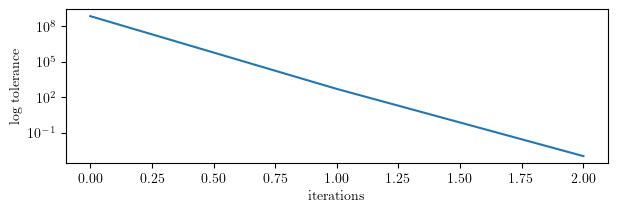

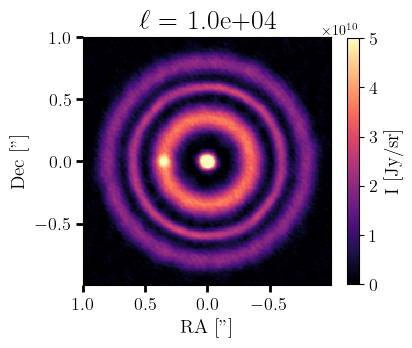

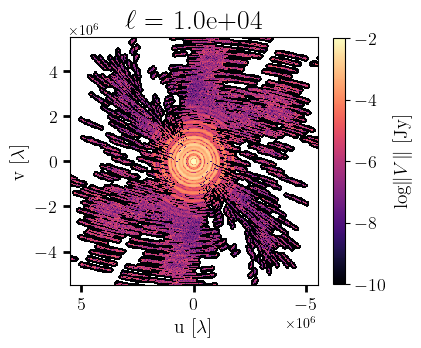

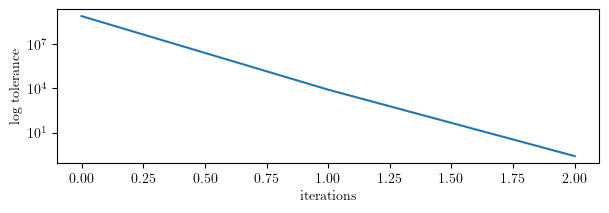

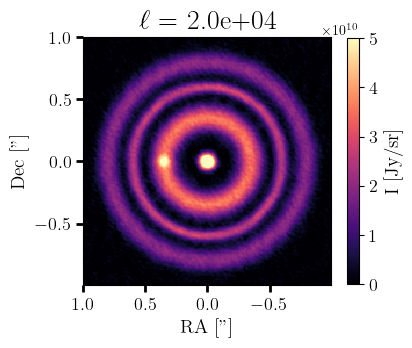

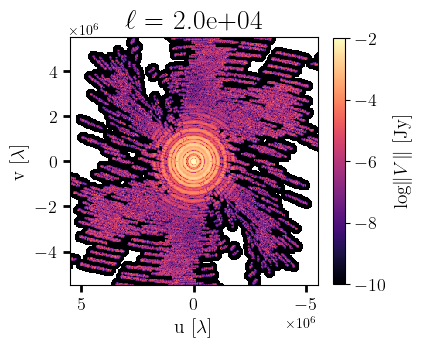

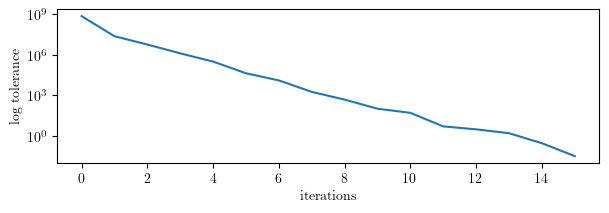

In [118]:
for i in frank2d_objects_se:
    Plot_se = Plot(i, geom)
    Plot_se.intensity(fig_size = 4, vmax=5e10, gamma = 1, zoom = 3, title = r'$\ell$' + f' = {l_se[frank2d_objects_se.index(i)]:.1e}')
    Plot_se.visibility(fig_size = 4, zoom =2, title= r'$\ell$' + f' = {l_se[frank2d_objects_se.index(i)]:.1e}')
    Plot_se.cg_tolerance()

In [123]:
l_se

[9000.0, 10000.0, 20000.0, 40000.0, 50000.0, 56439.474897224536, 100000.0]

In [124]:
l_se = l_se[:5]
l_se

[9000.0, 10000.0, 20000.0, 40000.0, 50000.0]

In [161]:
times_se[-2] = 3000
times_se[-1] = 18000

In [162]:
times_se

[3.899200439453125, 4.187215566635132, 8.657768726348877, 3000, 18000]

In [167]:
l_wend

[9000.0, 10000.0, 20000.0, 40000.0, 50000.0, 56439.474897224536, 100000.0]

In [238]:
custom_ticks = [9e3, 20000.0, 40000.0, 50000.0,  1e5]

def format_sci(x):
    # 1. Crear el string base tipo "9.0e+03"
    s = f"{x:.0e}"
    # 2. Separar la base ("9.0") del exponente ("+03")
    base, exponent = s.split('e')
    # 3. Convertir exponente a entero para quitar el "+" y los ceros extra (ej. "+03" -> 3)
    return f"${base} \\times 10^{{{int(exponent)}}}$"

# Aplicar a la lista
custom_labels = [format_sci(x) for x in custom_ticks]

print(custom_labels)

['$9 \\times 10^{3}$', '$2 \\times 10^{4}$', '$4 \\times 10^{4}$', '$5 \\times 10^{4}$', '$1 \\times 10^{5}$']


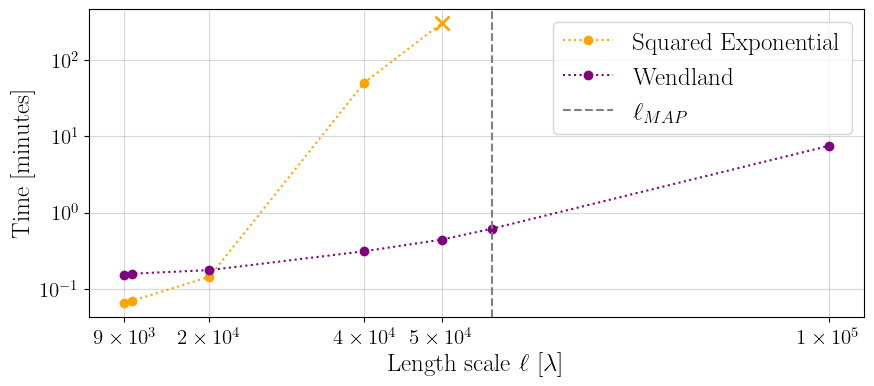

In [240]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,4))

y_se = np.array(times_se)/60

plt.plot(l_se, y_se, marker='o', ls=':', c='orange', 
         label='Squared Exponential', markevery=slice(0, -1))

plt.plot(l_se[-1], y_se[-1], marker='x', c='orange', 
         markersize=10, markeredgewidth=2) 

plt.plot(l_wend, np.array(times_wend)/60, marker='o', ls=':', color='purple', label='Wendland')

plt.yscale('log')
plt.xticks(custom_ticks, custom_labels)
plt.axvline(x=56439.474897224536, color='gray', linestyle='--', label='$\ell_{MAP}$')
plt.minorticks_off()

plt.xlabel(r'Length scale $\ell$ $[\lambda]$', size=18)
plt.ylabel('Time [minutes]', size=18)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(fontsize=18)
plt.tick_params(axis='both', labelsize=15)

plt.show()